In [1]:
from src.backend import TorchBackend
from src.model import Rectangle, Ellipse, Material, Lattice, Bitmap, Layer, Source, Model, Uniform

import torch
import numpy as np
import matplotlib.pyplot as plt

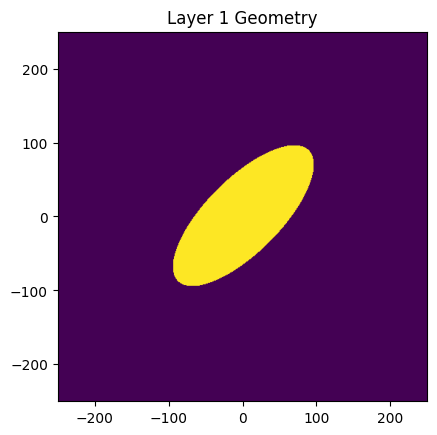

In [2]:
# Backend
device = torch.device("cuda:1" if torch.cuda.is_available() else "cpu")
dtype = torch.float64
backend = TorchBackend(device=device, dtype=dtype)

# Lattice
period = (500, 500)
grid = (501, 501)
M = 21
N = 21
lattice = Lattice(period=period, grid=grid, M=M, N=N)

# Materials
epsilon_inc = torch.nn.Parameter(torch.tensor([1.0, 1.0]), requires_grad=True)
mat_inc = Material(epsilon_inc)

epsilon_sub = torch.nn.Parameter(torch.tensor([1.46, 1.46]), requires_grad=True)
mat_sub = Material(epsilon_sub)

epsilon1 = torch.nn.Parameter(torch.tensor([4.0 + 0.1j, 1.0]), requires_grad=True)
epsilon1_bg = torch.nn.Parameter(torch.tensor([1.0]), requires_grad=True)
mat1 = Material(epsilon1)
mat1_bg = Material(epsilon1_bg)

# Geometry
obj_inc = Uniform(material=mat_inc)
obj_sub = Uniform(material=mat_sub)

center1 = torch.nn.Parameter(torch.tensor([0.0, 0.0]), requires_grad=True)
size1 = torch.nn.Parameter(torch.tensor([250.0, 100.0]), requires_grad=True)
angle1 = torch.nn.Parameter(torch.tensor(45.0*torch.pi/180), requires_grad=True)
d1 = torch.nn.Parameter(torch.tensor(300.0), requires_grad=True)
obj1 = Ellipse(center=center1, size=size1, angle=angle1, 
                material=mat1, soft_mask=False, smoothness=0.005)

# Layers
layer_inc = Layer(obj_inc, thickness=None, material_bg=mat_inc)
layer_sub = Layer(obj_sub, thickness=None, material_bg=mat_sub)
layer1 = Layer(obj1, thickness=d1, material_bg=mat1_bg)
plt.title("Layer 1 Geometry")
plt.imshow(layer1.bitmap(backend, lattice).cpu().numpy().T, origin='lower', extent=(-period[0]/2, period[0]/2, -period[1]/2, period[1]/2))
plt.show()
layers = [layer_inc, layer1, layer_sub]
   
# Source
wavelength = torch.tensor([700.0, 200.0])
theta = torch.tensor([20.0])*torch.pi/180
phi = torch.tensor([0.0])*torch.pi/180
src = Source(wavelength=wavelength, theta=theta, phi=phi)

# Model
model = Model(layers=layers, lattice=lattice, source=src, backend=backend)

In [10]:
model.layers[0].epsilon_xy(backend, lattice).shape

torch.Size([2, 3, 3, 501, 501])